In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
import os
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
! pip install kaggle

from google.colab import drive
drive.mount('/content/drive')

! cp /content/drive/MyDrive/Kaggle_API/kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cp: cannot create regular file '/root/.kaggle/': Not a directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [9]:
! kaggle datasets download -d misrakahmed/vegetable-image-dataset

Dataset URL: https://www.kaggle.com/datasets/misrakahmed/vegetable-image-dataset
License(s): CC-BY-SA-4.0
vegetable-image-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [8]:
! unzip vegetable-image-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Vegetable Images/train/Radish/0001.jpg  
  inflating: Vegetable Images/train/Radish/0002.jpg  
  inflating: Vegetable Images/train/Radish/0003.jpg  
  inflating: Vegetable Images/train/Radish/0004.jpg  
  inflating: Vegetable Images/train/Radish/0005.jpg  
  inflating: Vegetable Images/train/Radish/0006.jpg  
  inflating: Vegetable Images/train/Radish/0007.jpg  
  inflating: Vegetable Images/train/Radish/0008.jpg  
  inflating: Vegetable Images/train/Radish/0009.jpg  
  inflating: Vegetable Images/train/Radish/0010.jpg  
  inflating: Vegetable Images/train/Radish/0011.jpg  
  inflating: Vegetable Images/train/Radish/0012.jpg  
  inflating: Vegetable Images/train/Radish/0013.jpg  
  inflating: Vegetable Images/train/Radish/0014.jpg  
  inflating: Vegetable Images/train/Radish/0015.jpg  
  inflating: Vegetable Images/train/Radish/0016.jpg  
  inflating: Vegetable Images/train/Radish/0017.jpg  
  inflating: Vegetable Images/t

**Data Collection:**

In [10]:
train_dir = '/content/Vegetable Images/train'
test_dir = '/content/Vegetable Images/test'
validation_dir = '/content/Vegetable Images/validation'

def count_images(directory):
    return {category: len(os.listdir(os.path.join(directory, category))) for category in os.listdir(directory)}

train_count = count_images(train_dir)
test_count = count_images(test_dir)
validation_count = count_images(validation_dir)

print(f"Train sample count : {train_count}\n")
print(f"Test sample count : {test_count}\n")
print(f"Validation sample count : {validation_count}")

Train sample count : {'Broccoli': 1000, 'Potato': 1000, 'Bean': 1000, 'Bitter_Gourd': 1000, 'Tomato': 1000, 'Bottle_Gourd': 1000, 'Carrot': 1000, 'Capsicum': 1000, 'Radish': 1000, 'Cabbage': 1000, 'Brinjal': 1000, 'Pumpkin': 1000, 'Papaya': 1000, 'Cucumber': 1000, 'Cauliflower': 1000}

Test sample count : {'Broccoli': 200, 'Potato': 200, 'Bean': 200, 'Bitter_Gourd': 200, 'Tomato': 200, 'Bottle_Gourd': 200, 'Carrot': 200, 'Capsicum': 200, 'Radish': 200, 'Cabbage': 200, 'Brinjal': 200, 'Pumpkin': 200, 'Papaya': 200, 'Cucumber': 200, 'Cauliflower': 200}

Validation sample count : {'Broccoli': 200, 'Potato': 200, 'Bean': 200, 'Bitter_Gourd': 200, 'Tomato': 200, 'Bottle_Gourd': 200, 'Carrot': 200, 'Capsicum': 200, 'Radish': 200, 'Cabbage': 200, 'Brinjal': 200, 'Pumpkin': 200, 'Papaya': 200, 'Cucumber': 200, 'Cauliflower': 200}


In [20]:
batch_size = 32
num_classes = 15
learning_rate = 0.001
num_epochs = 25

**Data Preprocessing:**

Class labels: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']


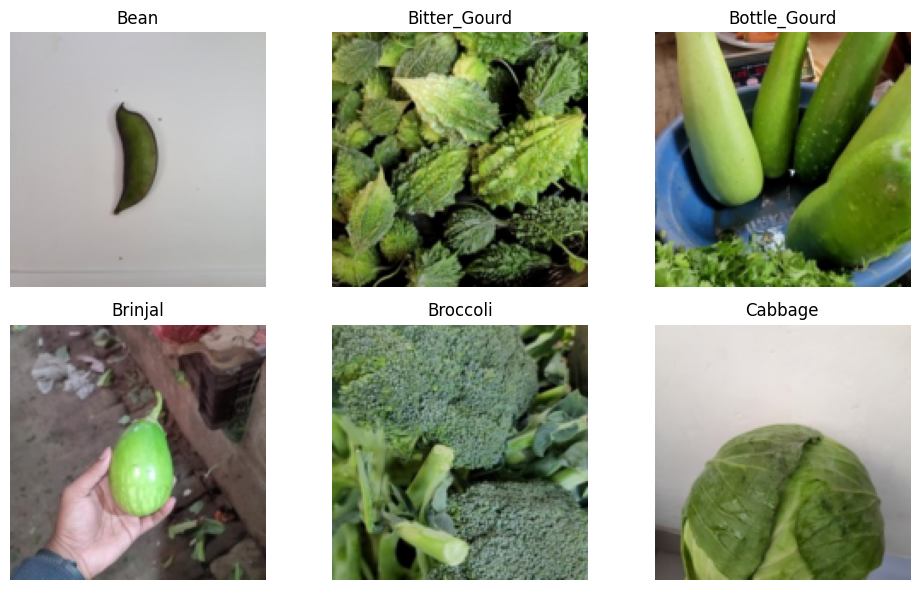

In [21]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

#normalization
transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size, shuffle=True)

validation_dataset = datasets.ImageFolder(root=validation_dir, transform=transform)
validation_loader = DataLoader(validation_dataset, batch_size, shuffle=False)

test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size, shuffle=False)

# Check the class labels
class_names = train_dataset.classes
print("Class labels:", class_names)


#plot

def unnormalize(img_tensor):
    # Reverse normalization: img = (img * std) + mean
    img = img_tensor * torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1) + torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
    return img

shown_classes = {}
def show_images(dataset, num_images=6):
  plt.figure(figsize = (10, 6))
  to_pil = transforms.ToPILImage()

  for i in range(len(dataset)):
    img_tensor, label = dataset[i]
    class_name = dataset.classes[label]

    # Only show one image per class
    if class_name not in shown_classes:
        img_tensor = unnormalize(img_tensor)
        img_pil = to_pil(img_tensor)

        # Plot the image
        plt.subplot(2, 3, len(shown_classes) + 1)
        plt.imshow(img_pil)
        plt.title(class_name)
        plt.axis('off')

        shown_classes[class_name] = True

        if len(shown_classes) == num_images:
            break
  plt.tight_layout()
  plt.show()

# Plot 6 train images in a 2x3 grid
show_images(train_dataset)

 **Define CNN Model:**

In [24]:
class ConvNet(nn.Module):

    def __init__(self, num_classes):

        super(ConvNet, self).__init__()

        # Our images are RGB, so input channels = 3. 32 filters are applied
        self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 32, kernel_size = 3, stride = 1, padding = 1)

        # 2nd cnn layer
        self.conv2 = nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, stride = 1, padding = 1)

        # 3rd cnn layer
        self.conv3 = nn.Conv2d(in_channels = 64, out_channels = 128, kernel_size = 3, stride = 1, padding = 1)

        # 4th cnn layer
        self.conv4 = nn.Conv2d(in_channels = 128, out_channels = 128, kernel_size = 3, stride = 1, padding = 1)

        # Pooling layer reduce image size by 2
        self.pool = nn.MaxPool2d(kernel_size = 2)

        # 128x128 image will be pooled twice with a kernel size of 2 -> size of image 150/2/2/2/2 = 9

        # fully connected layer map them to probability for each class
        self.fc1 = nn.Linear(in_features = 128 * 9 * 9, out_features = num_classes)

    def forward(self, x):

        x = F.relu(self.pool(self.conv1(x)))
        x = F.relu(self.pool(self.conv2(x)))
        x = F.relu(self.pool(self.conv3(x)))
        x = F.relu(self.pool(self.conv4(x)))

        # Used in training to generalize, turned off during evaluation to make accurate prediction
        #x = F.dropout(x, training = self.training)

        # Flatten
        x = x.view(-1, 128 * 9 * 9)

        # to predict class
        x = self.fc1(x)

        # Return log_softmax tensor
        return F.log_softmax(x, dim = 1)

print("CNN model class defined!")

CNN model class defined!


**Train & Validate Model :**

In [25]:
model = ConvNet(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)

for epoch in range(num_epochs):

  #train
  model.train()
  for i, (images, labels) in enumerate(train_loader):
    images = images.to(device)
    labels = labels.to(device)

    # Forward pass
    outputs = model(images)
    loss = criterion(outputs, labels)

    # Backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  print('Epoch [{}/{}], Loss: {:.4f}'.format(epoch + 1, num_epochs, loss.item()))

  #validate
  model.eval()
  with torch.no_grad():
    correct = 0
    total = 0
    valid_loss = 0

    for images, labels in validation_loader:
      images = images.to(device)
      labels = labels.to(device)
      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
      valid_loss += loss.item()

  avg_valid_loss = valid_loss / len(validation_loader)
  accuracy = 100 * correct / total
  print('Accuracy of the network on the {:.4f} validation images: {:.2f}%'.format(avg_valid_loss, accuracy))

Epoch [1/25], Loss: 2.7029
Accuracy of the network on the 2.7029 validation images: 6.73%
Epoch [2/25], Loss: 2.6987
Accuracy of the network on the 2.6987 validation images: 11.07%
Epoch [3/25], Loss: 2.6926
Accuracy of the network on the 2.6926 validation images: 10.13%
Epoch [4/25], Loss: 2.6422
Accuracy of the network on the 2.6422 validation images: 12.07%
Epoch [5/25], Loss: 2.5985
Accuracy of the network on the 2.5985 validation images: 18.80%
Epoch [6/25], Loss: 2.3523
Accuracy of the network on the 2.3523 validation images: 27.63%
Epoch [7/25], Loss: 1.7623
Accuracy of the network on the 1.7623 validation images: 32.47%
Epoch [8/25], Loss: 2.1466
Accuracy of the network on the 2.1466 validation images: 35.83%
Epoch [9/25], Loss: 1.6223
Accuracy of the network on the 1.6223 validation images: 43.60%
Epoch [10/25], Loss: 1.4395
Accuracy of the network on the 1.4395 validation images: 47.07%
Epoch [11/25], Loss: 1.2362
Accuracy of the network on the 1.2362 validation images: 53.77

**Testing:**

In [26]:
with torch.no_grad():
  correct = 0
  total = 0
  test_loss = 0

  for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
    test_loss += loss.item()

  avg_test_loss = test_loss / len(test_loader)
  accuracy = 100 * correct / total
  print('Accuracy of the network on the {:.4f} test images: {:.2f}%'.format(avg_test_loss, accuracy))



Accuracy of the network on the 0.5548 test images: 84.17%
